# 02.1 TF-IDF Training

TF-IDF is the process of assigning weights to words. TF is term frequency, or how many times a word appears in a data entry, and IDF is inverse document frequency, or how unique the word is across the dataset. The output of the TF-IDF features is a list of weights, one for each word. Common words are given less weight, and Less common words are given more weight.

The training of models using TF-IDF vectors is a relatively quick and inexpensive process, so we'll be running some experiments to optimize it's ability.

Goal: Using traditional scientific methods, determine the best configuration of the TF-IDF model
1. For each configuration...
    a. Vectorize the articles
    b. Run the logistic regression model on the vectorized dataset
    c. Analyze metrics like accuracy and precision
    d. Store the input (configuration) and output (metrics) of the model

Output:
1. A csv file tracking tests of the model for use in determining optimal configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
import pickle
import os
import datetime


In [2]:
filename = "../../data/processed/01/reduced_dataset.csv"
df = pd.read_csv(filename, encoding='utf-8')

print(f"{len(df)} rows")
print(f"columns: {df.columns.tolist()}")
df.head()


58501 rows
columns: ['Article', 'Truth', 'Source']


,Article,Truth,Source
0,celebrities join tax march protest donald trum...,0,gossipcop
1,heres really happened jfk jr met princess dian...,0,gossipcop
2,angelina jolie cant get heartbreak losing brad...,0,gossipcop
3,oscar nominations 2018 complete list oscar nom...,0,gossipcop
4,hes hired ben affleck enlists best friend matt...,0,gossipcop


In [3]:
# === EXPERIMENT CONFIGURATION ===
config = {
    "source_filter": None,   # e.g. "Reuters", or None for all
    "sample_size": 9999999,     # number of samples to use from total data
    "max_features": 20000,    # TF-IDF max words
    "ngram_range": (1, 2),   # e.g. (1,1) for unigrams, (1,2) for bigrams
    "test_size": 0.2,
    "random_state": 42,
    "model_type": "LogisticRegression",
    "model_params": {"max_iter": 200}
}


In [4]:
df_filtered = df.copy()

# Filter by source
if config["source_filter"]:
    df_filtered = df_filtered[df_filtered["Source"] == config["source_filter"]]
    print(f"Filtered by source '{config['source_filter']}' → {len(df_filtered)} rows remain")

# Random sample
if config["sample_size"] and len(df_filtered) > config["sample_size"]:
    df_filtered = df_filtered.sample(config["sample_size"], random_state=config["random_state"])
    print(f"Using random sample of {len(df_filtered)} rows")

# Prepare X, y
X_text = df_filtered["Article"].values
y = df_filtered["Truth"].values


In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=config["max_features"],
    ngram_range=config["ngram_range"]
)

X = vectorizer.fit_transform(X_text)
print(f"matrix shape post filter: {X.shape}")


matrix shape post filter: (58501, 20000)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=config["test_size"],
    random_state=config["random_state"]
)


In [7]:
model = LogisticRegression(**config["model_params"])
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [8]:
y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_score)
}

metrics


{'Accuracy': 0.9518844543201436,
 'Precision': 0.9458511287370348,
 'Recall': 0.9675456389452333,
 'F1': 0.9565753952950251,
 'ROC_AUC': 0.9892381060882944}

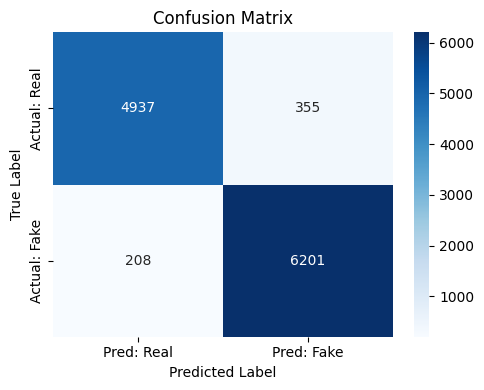

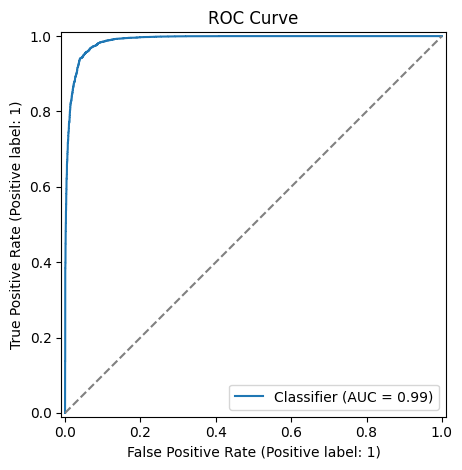

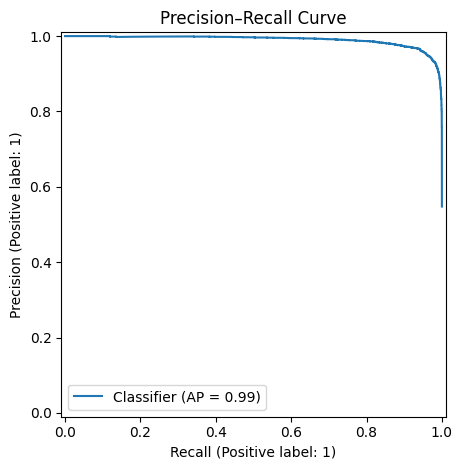

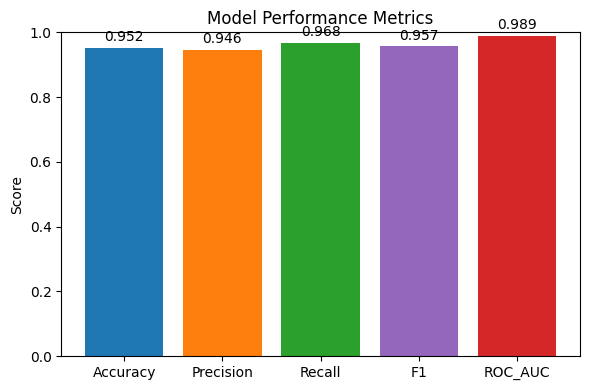

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred: Real', 'Pred: Fake'], yticklabels=['Actual: Real', 'Actual: Fake'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 2️⃣ ROC Curve
RocCurveDisplay.from_predictions(y_test, y_score)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.tight_layout()
plt.show()

# 3️⃣ Precision–Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_score)
plt.title('Precision–Recall Curve')
plt.tight_layout()
plt.show()

# 4️⃣ Metric Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728'])
plt.title('Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()


In [10]:
log_entry = {
    "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    **config,
    **metrics
}

log_entry["model_params"] = str(config["model_params"])
log_entry["ngram_range"] = str(config["ngram_range"])
log_path = "experiment_log.csv"

# Append or create file
if not os.path.exists(log_path):
    pd.DataFrame([log_entry]).to_csv(log_path, index=False)
    print(f"Created new experiment log: {log_path}")
else:
    pd.DataFrame([log_entry]).to_csv(log_path, mode='a', header=False, index=False)
    print(f"Appended new result to {log_path}")

pd.read_csv(log_path).tail() # check if it added properly


Created new experiment log: experiment_log.csv


,timestamp,source_filter,sample_size,max_features,ngram_range,test_size,random_state,model_type,model_params,Accuracy,Precision,Recall,F1,ROC_AUC
0,2025-10-21 18:36:58,NaN,9999999,20000,"(1, 2)",0.2,42,LogisticRegression,{'max_iter': 200},0.951884,0.945851,0.967546,0.956575,0.989238


In [11]:
pickle.dump(model, open("../../models/tfidf_model.pkl", "wb"))
pickle.dump(vectorizer, open("../../models/tfidf_vectorizer.pkl", "wb"))